## **`Data Preparation`**

In [3]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, recall_score, accuracy_score, confusion_matrix, f1_score, matthews_corrcoef
from imblearn.ensemble import BalancedRandomForestClassifier


In [4]:
# Load the dataset
chronic_kidney_disease = 'chronic_kidney_disease.csv'

# To display all the columns
pd.options.display.max_columns = None

# To display all the rows
pd.options.display.max_rows = None

# To map Empty Strings or numpy.inf as Na Values
pd.options.mode.use_inf_as_na = True

pd.options.display.expand_frame_repr =  False

%matplotlib inline

# Set Style
sns.set(style = "whitegrid")

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')


chronic_kidney_disease_df = pd.read_csv(chronic_kidney_disease)

C:\Users\Asus\AppData\Local\Temp\ipykernel_21616\1555632518.py:11: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [5]:
chronic_kidney_disease_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  491 non-null    int64  
 1   AgeBaseline          491 non-null    int64  
 2   HistoryDiabetes      491 non-null    int64  
 3   HistoryCHD           491 non-null    int64  
 4   HistoryVascular      491 non-null    int64  
 5   HistorySmoking       491 non-null    int64  
 6   HistoryHTN           491 non-null    int64  
 7   HistoryDLD           491 non-null    int64  
 8   HistoryObesity       491 non-null    int64  
 9   DLDmeds              491 non-null    int64  
 10  DMmeds               491 non-null    int64  
 11  HTNmeds              491 non-null    int64  
 12  ACEIARB              491 non-null    int64  
 13  CholesterolBaseline  491 non-null    float64
 14  CreatinineBaseline   491 non-null    float64
 15  eGFRBaseline         491 non-null    flo

> The original dataframe has total of 491 entries with 22 columns, with no missing values.

In [6]:
chronic_kidney_disease_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sex,491.0,0.509165,0.500426,0.00,0.0,1.0,1.00,1.0
AgeBaseline,491.0,53.203666,13.821282,23.00,44.0,54.0,64.00,89.0
HistoryDiabetes,491.0,0.437882,0.496632,0.00,0.0,0.0,1.00,1.0
HistoryCHD,491.0,0.091650,0.288825,0.00,0.0,0.0,0.00,1.0
HistoryVascular,491.0,0.059063,0.235983,0.00,0.0,0.0,0.00,1.0
HistorySmoking,491.0,0.152749,0.360113,0.00,0.0,0.0,0.00,1.0
HistoryHTN,491.0,0.682281,0.466064,0.00,0.0,1.0,1.00,1.0
HistoryDLD,491.0,0.645621,0.478812,0.00,0.0,1.0,1.00,1.0
HistoryObesity,491.0,0.505092,0.500484,0.00,0.0,1.0,1.00,1.0
DLDmeds,491.0,0.551935,0.497803,0.00,0.0,1.0,1.00,1.0


In [7]:
chronic_kidney_disease_df.head()

,Sex,AgeBaseline,HistoryDiabetes,HistoryCHD,HistoryVascular,HistorySmoking,HistoryHTN,HistoryDLD,HistoryObesity,DLDmeds,DMmeds,HTNmeds,ACEIARB,CholesterolBaseline,CreatinineBaseline,eGFRBaseline,sBPBaseline,dBPBaseline,BMIBaseline,TimeToEventMonths,EventCKD35,TIME_YEAR
0,0,64,0,0,0,0,1,1,1,1,0,1,0,4.8,59.0,93.3,144,87,40,98,0,8
1,0,52,0,0,0,0,1,1,1,0,0,1,0,6.4,52.0,105.8,148,91,45,106,0,9
2,0,56,0,0,0,0,1,1,1,1,0,1,0,6.4,57.0,99.8,149,86,41,88,0,7
3,0,58,0,0,0,0,0,1,1,1,0,0,0,5.1,65.0,90.3,116,68,32,103,0,9
4,0,63,1,0,0,0,1,1,1,1,1,1,1,5.0,70.0,79.7,132,63,31,105,0,9


#### **`Observation of initial data`**
1. All of the data seems to have been imported. 
2. Data types:  
3. There seems to be no NULL values.
4. There seems to be no duplicated values.


In [8]:
# List of categorical features
chronic_kidney_disease_df.columns = chronic_kidney_disease_df.columns.str.strip()
categorical_features = ['Sex', 'HistoryCHD', 'HistoryVascular', 'HistorySmoking', 'HistoryHTN', 'HistoryDLD', 'HistoryObesity', 
                         'DLDmeds', 'DMmeds', 'HTNmeds', 'ACEIARB']
print([f"'{col}'" for col in chronic_kidney_disease_df.columns])

# Convert to category type
for feature in categorical_features:
   chronic_kidney_disease_df[feature] = chronic_kidney_disease_df[feature].astype('category')


["'Sex'", "'AgeBaseline'", "'HistoryDiabetes'", "'HistoryCHD'", "'HistoryVascular'", "'HistorySmoking'", "'HistoryHTN'", "'HistoryDLD'", "'HistoryObesity'", "'DLDmeds'", "'DMmeds'", "'HTNmeds'", "'ACEIARB'", "'CholesterolBaseline'", "'CreatinineBaseline'", "'eGFRBaseline'", "'sBPBaseline'", "'dBPBaseline'", "'BMIBaseline'", "'TimeToEventMonths'", "'EventCKD35'", "'TIME_YEAR'"]


### **`Data Exploration`**
Five columns or column pairings of the training data set will be visualized and explored. The methodology and the observation will be provided after each visualization.

In [9]:
# Utility Function for labelling
def label_plot(title, xlabel, ylabel):
    """"
    Customize the plot with the title, x and y labels.
    :Params:
        title (str): Title of plot
        xlabel (str): X axis Label
        ylabel(str) : Y axis label
    """
    plt.title(title, fontsize=16)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid()
    plt.show()

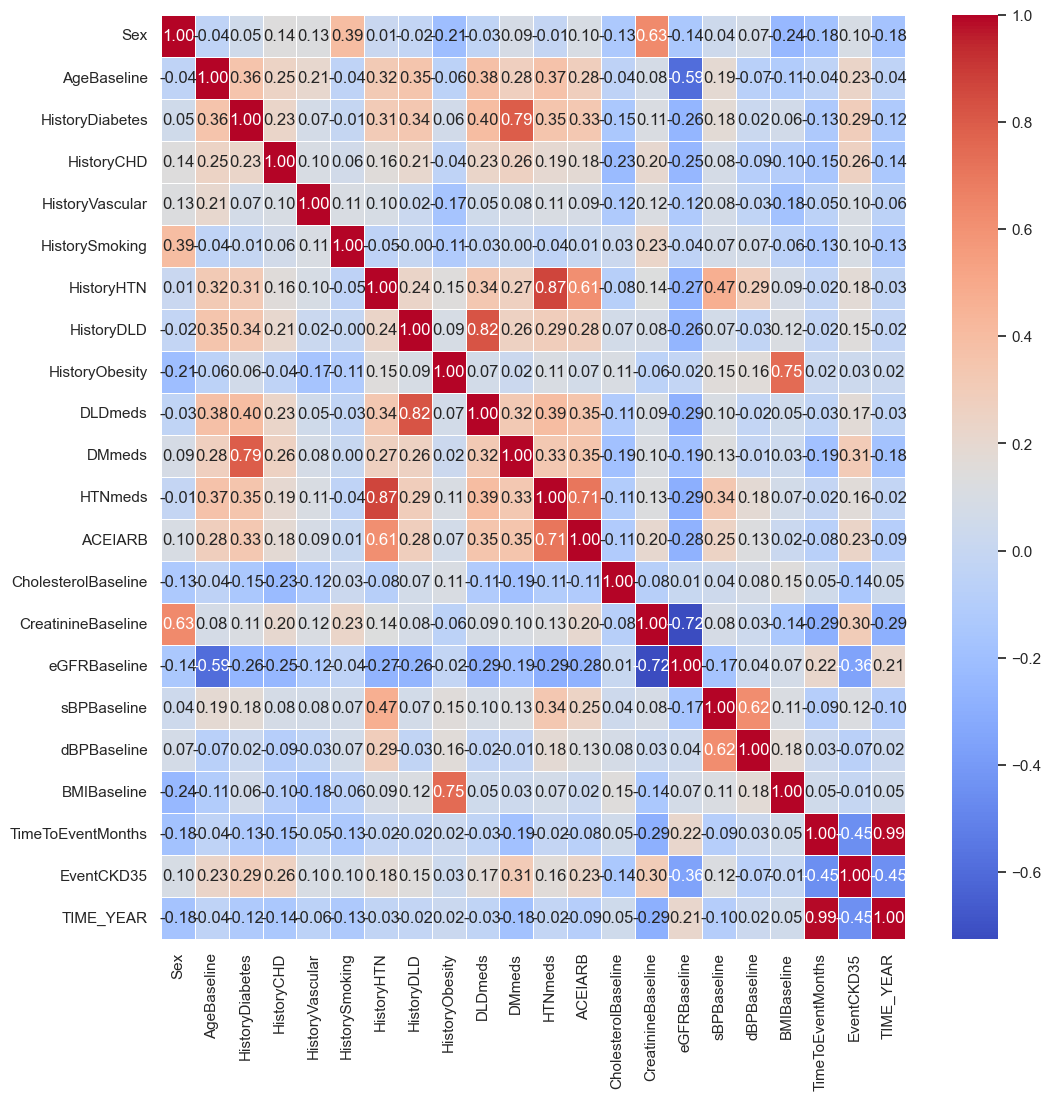

AgeBaseline           0.234616
HistoryDiabetes       0.290294
HistoryCHD            0.263532
DMmeds                0.308959
ACEIARB               0.232300
CreatinineBaseline    0.299953
eGFRBaseline         -0.359031
TimeToEventMonths    -0.449169
EventCKD35            1.000000
TIME_YEAR            -0.447710
Name: EventCKD35, dtype: float64

In [11]:
# Feature engineering
# Correlation analysis
fig, ax = plt.subplots(figsize = (12,12))
correlation_map = chronic_kidney_disease_df.corr()
sns.heatmap(correlation_map, annot =True, fmt=".2f", linewidths = 0.5, cmap="coolwarm")
plt.show()

# Identifying features with strong correlation to the target
correlation_map[abs(correlation_map['EventCKD35']) > 0.2]['EventCKD35']

#### **`Observation of the correlation matrix`** 
--------------
It seems that the time_year and time to event months have the highest negative correlation with the EventCKD35. The DMMeds has the highest positive correlation with EventCKD35. This is followed closely by History of Diabetes and Creatinine Baseline Levls. CHD, Age, ACEIARB and eGFRBaseline also seem to be closely correlated with CKD Risk. 

In [12]:
# Ensure there are no NaN values in the target variable
chronic_kidney_disease_df = chronic_kidney_disease_df.dropna(subset=['EventCKD35'])

In [13]:
def train_ckd_model(df, target_col, features, threshold=0.6):
    """
    Cleans, splits, and trains the model
    """
    try: 
        X = df[features]
        y = df[target_col]
        
        # Split the data (Prevent data leakage)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        
        # Imputation
        for col in X_train.columns:
            try:
                # Numerical features
                fill_val = X_train[col].median()
            except:
                # Categorical features
                fill_val = X_train[col].mode()[0]
            
            X_train[col] = X_train[col].fillna(fill_val)
            X_test[col] = X_test[col].fillna(fill_val)
        
        # Encoding
        X_train = pd.get_dummies(X_train, drop_first=True)
        X_test = pd.get_dummies(X_test, drop_first=True)
        X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)  
        
        model = BalancedRandomForestClassifier(
            n_estimators=400,
            sampling_strategy='all',
            replacement=True,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train) 

        # Threshold
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs >= threshold).astype(int)
        
        print(f"n\--- Results (Threshold: {threshold}) ---")
        print(confusion_matrix(y_test, y_pred))
        print(classification_report(y_test, y_pred))
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        
        return model, X_train.columns
    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None
        

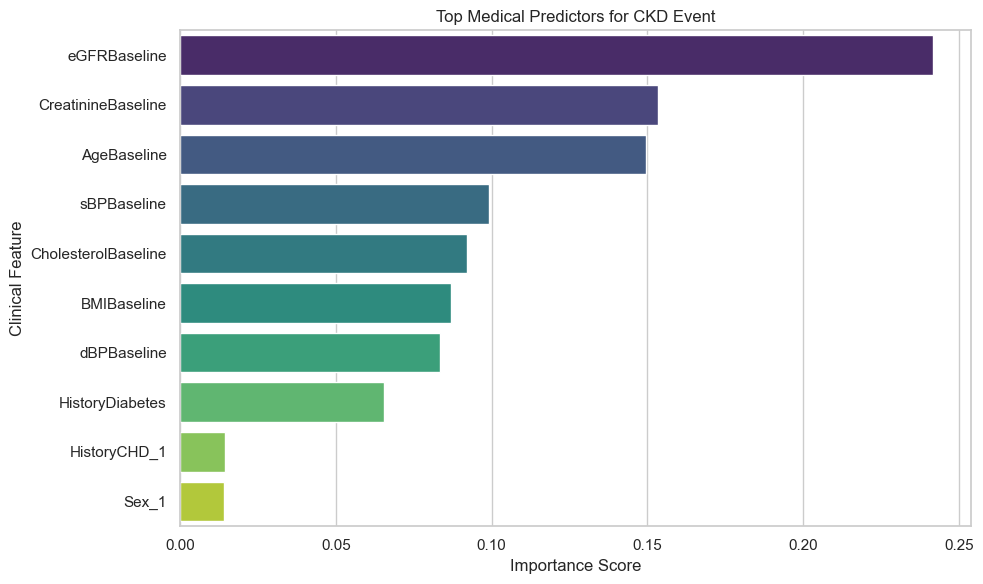

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_feature_importance(model, feature_names):
    """
    Creates a bar plot of feature importance for the trained model.
    
    arg:
        model: The trained RandomForest or BalancedRandomForest model.
        feature_names: List of column names used during training.
    """
    try:
        # Create a DataFrame for visualization
        importances = model.feature_importances_
        feat_imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        # Plotting
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
        
        plt.title('Top Medical Predictors for CKD Event')
        plt.xlabel('Importance Score')
        plt.ylabel('Clinical Feature')
        plt.tight_layout()
        plt.show()
        
        return feat_imp_df

    except Exception as e:
        print(f"Failed to plot importance: {e}")
        return None

importance_data = plot_feature_importance(model_final, final_cols)

In [14]:
top_features = ['Sex', 'eGFRBaseline', 'AgeBaseline', 'CreatinineBaseline', 
                'dBPBaseline', 'sBPBaseline', 'CholesterolBaseline', 
                'BMIBaseline', 'HistoryCHD', 'HistoryDiabetes']

model_final, final_cols = train_ckd_model(chronic_kidney_disease_df, 'EventCKD35', top_features)

if model_final:
    os.makedirs('models', exist_ok=True)
    with open('models/ckd_model.pkl', 'wb') as f:
        pickle.dump({'model': model_final, 'threshold': 0.6, 'columns': final_cols}, f)
    print("Model saved successfully.")

n\--- Results (Threshold: 0.6) ---
[[81  7]
 [ 1 10]]
              precision    recall  f1-score   support

           0       0.99      0.92      0.95        88
           1       0.59      0.91      0.71        11

    accuracy                           0.92        99
   macro avg       0.79      0.91      0.83        99
weighted avg       0.94      0.92      0.93        99

Accuracy: 0.9192
Model saved successfully.
